<a href="https://colab.research.google.com/github/srija-guda/Anomalies-in-WBAN-MIMIC4/blob/main/MM-MIMIC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input, Dropout,Bidirectional
import matplotlib.pyplot as plt
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential

In [2]:
df = pd.read_csv('final_data.csv')

In [3]:
df.head()

,charttime,ABPd,ABPm,ABPs,HR,RR,SpO2,Temperature C,point_anomaly,contextual_anomaly,final_label
0,2160-05-18 14:06:00,75.0,94.0,134.0,80.0,14.0,100.0,37.2,0,0,0
1,2160-05-18 14:07:00,75.0,94.0,134.0,80.0,14.0,100.0,37.2,0,0,0
2,2160-05-18 14:18:00,75.0,94.0,134.0,80.0,14.0,100.0,37.2,0,0,0
3,2160-05-18 15:00:00,55.0,66.0,90.0,88.0,14.0,100.0,37.0,0,0,0
4,2160-05-18 16:00:00,70.0,88.0,122.0,92.0,14.0,100.0,36.9,0,0,0


In [4]:
df = df.drop(columns=['charttime'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143694 entries, 0 to 143693
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   ABPd                143694 non-null  float64
 1   ABPm                143694 non-null  float64
 2   ABPs                143694 non-null  float64
 3   HR                  143694 non-null  float64
 4   RR                  143694 non-null  float64
 5   SpO2                143694 non-null  float64
 6   Temperature C       143694 non-null  float64
 7   point_anomaly       143694 non-null  int64  
 8   contextual_anomaly  143694 non-null  int64  
 9   final_label         143694 non-null  int64  
dtypes: float64(7), int64(3)
memory usage: 11.0 MB


In [6]:
df.isna().sum()

,0
ABPd,0
ABPm,0
ABPs,0
HR,0
RR,0
SpO2,0
Temperature C,0
point_anomaly,0
contextual_anomaly,0
final_label,0


In [7]:
scaler = MinMaxScaler()
numerical_features = df.select_dtypes(include=['number']).columns
df[numerical_features] = scaler.fit_transform(df[numerical_features])

In [8]:
df.describe()

,ABPd,ABPm,ABPs,HR,RR,SpO2,Temperature C,point_anomaly,contextual_anomaly,final_label
count,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000,143694.000000
mean,0.331169,0.151798,0.431801,0.193761,0.448404,0.153436,0.578309,0.047831,0.041129,0.044480
std,0.153916,0.072507,0.155583,0.083006,0.173055,0.056475,0.115624,0.213409,0.198589,0.202055
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.109566,0.333333,0.137662,0.314286,0.137726,0.533333,0.000000,0.000000,0.000000
50%,0.311111,0.139791,0.413333,0.183549,0.428571,0.148321,0.583333,0.000000,0.000000,0.000000
75%,0.422222,0.181351,0.526667,0.240909,0.542857,0.158915,0.633333,0.000000,0.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
train_size = int(len(df) * 0.67)
test_size = len(df) - train_size

In [10]:
# def create_dataset(dataset, look_back=1):
#     dataX, dataY = [], []
#     for i in range(len(dataset) - look_back - 1):
#         a = dataset.iloc[i:(i + look_back), :].values
#         dataX.append(a)
#         dataY.append(dataset.iloc[i + look_back, 0])
#     return np.array(dataX), np.array(dataY)

In [11]:
columns = ['ABPd', 'ABPm',	'ABPs',	'HR' ,'RR',	'SpO2',	'Temperature C']

In [12]:
def LSTM_encoder_custom(seq_length, num_features):
    inputs = Input(shape=(seq_length, num_features))

    # Encoder
    encoded = LSTM(32, activation='relu', return_sequences=True)(inputs)
    encoded = LSTM(16, activation='relu', return_sequences=True)(encoded)
    encoded=Dropout(0.2)(encoded)
    encoded = LSTM(8, activation='relu', return_sequences=False)(encoded)
    # Decoder
    decoded = RepeatVector(seq_length)(encoded)
    decoded = LSTM(8, activation='relu', return_sequences=True)(decoded)
    decoded = LSTM(16, activation='relu', return_sequences=True)(decoded)
    decoded=Dropout(0.2)(decoded)
    decoded = LSTM(32, activation='relu', return_sequences=True)(decoded)
    decoded = TimeDistributed(Dense(num_features, activation='linear', kernel_regularizer=l2(0.001)))(decoded)
    model = Model(inputs, decoded)
    model.compile(optimizer=Adam(learning_rate=0.008), loss='mse')

    return model

In [13]:
seq_len=1
EPOCH = 20

In [14]:
def create_dataset(X, time_steps=1):
    Xs= []
    for i in range(len(X)-time_steps+1):
        v=X[i:(i+time_steps)]
        Xs.append(v)
    return np.array(Xs)

In [15]:
data_w=df
data_train = data_w.sample(frac=0.7, random_state=1)
data_test = data_w.drop(data_train.index)
data_train_n=data_train[data_train['point_anomaly']==0]

In [16]:
columns = ['ABPd', 'ABPm',	'ABPs',	'HR' ,'RR',	'SpO2',	'Temperature C']
mse_train_temp = []
mse_test_temp = []
mse_train_hr=[]
mse_test_hr=[]
mse_train_rr=[]
mse_test_rr=[]
mse_train_spo2=[]
mse_test_spo2=[]
mse_train_abpd=[]
mse_test_abpd=[]
mse_train_abpm=[]
mse_test_abpm=[]
mse_train_abps=[]
mse_test_abps=[]

In [17]:
feat = 'ABPd'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_abpd=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_abpd=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: ABPd
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 0.1735 - val_loss: 0.0307
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0085 - val_loss: 0.0316
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0071 - val_loss: 0.0481
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0054 - val_loss: 0.0500
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 6ms/step - loss: 0.0047 - val_loss: 0.0527
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0035 - val_loss: 0.0594
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [18]:
X_train.shape

(95740, 1, 1)

In [19]:
X_test.shape

(100586, 1, 1)

In [20]:
feat = 'ABPm'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_abpm=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_abpm=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: ABPm
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 28s 7ms/step - loss: 0.2159 - val_loss: 0.1033
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0114 - val_loss: 0.1497
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.0080 - val_loss: 0.1551
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0071 - val_loss: 0.1426
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 22s 8ms/step - loss: 0.0050 - val_loss: 0.1910
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 21s 8ms/step - loss: 0.0053 - val_loss: 0.2129
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [21]:
feat = 'ABPs'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_abps=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_abps=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: ABPs
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 30s 8ms/step - loss: 1.0148 - val_loss: 1.0025
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.0027 - val_loss: 1.0011
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 0.9971 - val_loss: 1.0011
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 1.0054 - val_loss: 1.0065
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - loss: 0.9985 - val_loss: 1.0028
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.9962 - val_loss: 1.0012
Epoch 7/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.9993 - val_loss: 1.0018
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [22]:
feat = 'HR'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_hr=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_hr=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: HR
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - loss: 0.9987 - val_loss: 0.9887
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.0060 - val_loss: 0.9884
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1.0128 - val_loss: 0.9884
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.9996 - val_loss: 0.9885
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 1.0037 - val_loss: 0.9885
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.9937 - val_loss: 0.9892
Epoch 7/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - loss: 1.0079 - val_loss: 0.9887
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [23]:
feat = 'RR'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_rr=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_rr=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: RR
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 28s 8ms/step - loss: 0.2049 - val_loss: 0.0568
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 22s 9ms/step - loss: 0.0074 - val_loss: 0.0697
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0055 - val_loss: 0.0658
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0048 - val_loss: 0.0638
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0043 - val_loss: 0.0687
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0040 - val_loss: 0.0747
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [24]:
feat = 'SpO2'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_spo2=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_spo2=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: SpO2
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 31s 8ms/step - loss: 0.3098 - val_loss: 0.1149
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0171 - val_loss: 0.2583
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - loss: 0.0143 - val_loss: 0.4003
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 18s 7ms/step - loss: 0.0138 - val_loss: 0.4857
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0175 - val_loss: 0.6393
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0117 - val_loss: 0.6183
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step


In [25]:
feat = 'Temperature C'
print('Feature:',feat)
model=LSTM_encoder_custom(seq_len,1)
scaler=StandardScaler()
callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
X_train=data_train_n[feat]
X_train=scaler.fit_transform(np.array(X_train).reshape(-1,1))
X_train=create_dataset(X_train,seq_len)
# print(X_train.shape)
model.fit(X_train,X_train,epochs=EPOCH,batch_size=32,validation_split=0.2,callbacks=[callback])
X_train_pred=model.predict(X_train)
mse_train_temp=np.mean(np.power(X_train-X_train_pred,2),axis=1)
X_test=data_train[feat].values
Y_test=data_train['point_anomaly'].values
X_test=scaler.fit_transform(np.array(X_test).reshape(-1,1))
X_test=create_dataset(X_test,seq_len)
X_test_pred=model.predict(X_test)
mse_test_temp=np.mean(np.power(X_test-X_test_pred,2),axis=1)

Feature: Temperature C
Epoch 1/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - loss: 0.1669 - val_loss: 0.0391
Epoch 2/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 19s 7ms/step - loss: 0.0127 - val_loss: 0.0793
Epoch 3/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0090 - val_loss: 0.0691
Epoch 4/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 16s 7ms/step - loss: 0.0074 - val_loss: 0.0851
Epoch 5/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - loss: 0.0077 - val_loss: 0.0925
Epoch 6/20
2394/2394 ━━━━━━━━━━━━━━━━━━━━ 17s 7ms/step - loss: 0.0067 - val_loss: 0.0688
2992/2992 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
3144/3144 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step


In [67]:
K = 7  # Number of features
rmse = np.sqrt((mse_train_rr + mse_train_spo2 + mse_train_hr + mse_train_abps + mse_train_temp+ mse_train_abpm + mse_train_abpd) / K)

In [68]:
rmse.shape

(95740, 1)

In [69]:
X_train.shape

(95740, 1, 1)

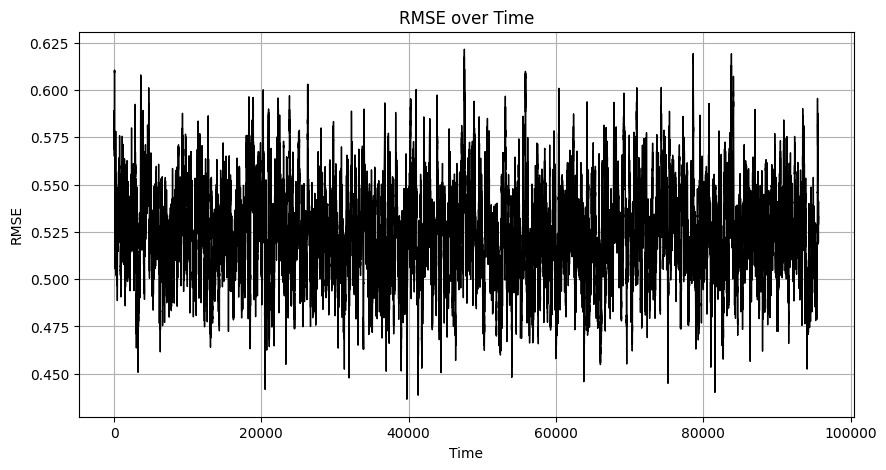

In [70]:
time = range(0, 95740)
window_size = 100
rmse = rmse.flatten()
rmse_smooth = np.convolve(rmse, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(time[:len(rmse_smooth)], rmse_smooth, linestyle='-', linewidth=1, color='black')  # Thin black line
plt.xlabel('Time')
plt.ylabel('RMSE')
plt.title('RMSE over Time')
plt.grid(True)

plt.show()

In [71]:
Q1 = np.quantile(rmse, 0.25)
Q2 = np.quantile(rmse, 0.5)
Q3 = np.quantile(rmse, 0.75)
IQR = Q3 - Q1
Min = Q1- 3*IQR
Max = Q3 + 3*IQR

In [72]:
TRW = []
for i in range(len(rmse)):
    if rmse[i] > Min and rmse[i] < Q1:
        state = 0
    elif rmse[i] > Q1 and rmse[i] < Q2:
        state = 1
    elif rmse[i] > Q2 and rmse[i] < Q3:
        state = 2
    elif rmse[i] > Q3 and rmse[i] < Max:
        state = 3
    TRW.append(state)

In [73]:
q0 = TRW.count(0)/len(TRW)
q1 = TRW.count(1)/len(TRW)
q2 = TRW.count(2)/len(TRW)
q3 = TRW.count(3)/len(TRW)

Q = [q0, q1, q2, q3]

print(Q)

[0.25040735324838104, 0.2504595780238145, 0.25042824315855444, 0.24870482556925005]


In [74]:
Q

[0.25040735324838104,
 0.2504595780238145,
 0.25042824315855444,
 0.24870482556925005]

In [75]:
states = np.unique(TRW)
num_states = len(states)

N = np.zeros((num_states, num_states), dtype=int)

for i in range(len(TRW) - 1):
    current_state = TRW[i]
    next_state = TRW[i + 1]
    N[current_state, next_state] += 1

T = np.sum(N, axis=1, keepdims=True)

P = np.divide(N, T, where=(T != 0))  # Avoid division by zero

print("Transition Count Matrix (N):\n", N)
print("Outgoing Transitions (T):\n", T.flatten())
print("Transition Probability Matrix (P):\n", P)

Transition Count Matrix (N):
 [[6123 5933 5992 5926]
 [5973 6088 5901 6016]
 [5858 6034 6110 5974]
 [6020 5923 5973 5895]]
Outgoing Transitions (T):
 [23974 23978 23976 23811]
Transition Probability Matrix (P):
 [[0.25540169 0.24747643 0.24993743 0.24718445]
 [0.24910334 0.25389941 0.24610059 0.25089666]
 [0.24432766 0.25166834 0.25483817 0.24916583]
 [0.25282432 0.24875058 0.25085045 0.24757465]]


In [76]:
rmse_test = np.sqrt((mse_test_rr + mse_test_spo2 + mse_test_hr + mse_test_abps + mse_test_temp+ mse_test_abpm + mse_test_abpd) / K)

In [77]:
rmse

array([0.44408437, 0.52461066, 0.27008205, ..., 0.11261584, 0.61259597,
       0.468584  ])

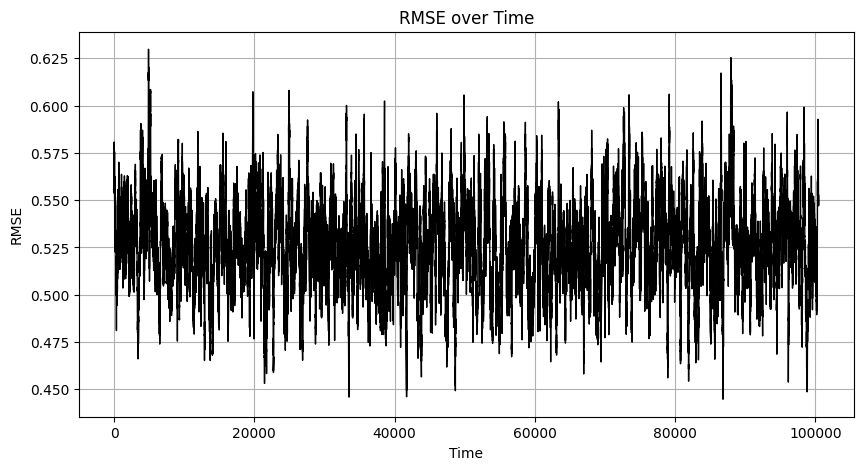

In [78]:
rmse_test = rmse_test.flatten()
time = range(0, len(rmse_test))
window_size = 150
rmse_smooth = np.convolve(rmse_test, np.ones(window_size)/window_size, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(time[:len(rmse_smooth)], rmse_smooth, linestyle='-', linewidth=1, color='black')  # Thin black line
plt.xlabel('Time')
plt.ylabel('RMSE')
plt.title('RMSE over Time')
plt.grid(True)

plt.show()

In [79]:
Q1_test = np.quantile(rmse_test, 0.25)
Q2_test = np.quantile(rmse_test, 0.5)
Q3_test = np.quantile(rmse_test, 0.75)
IQR_test = Q3_test - Q1_test
Min_test = Q1_test- 3*IQR_test
Max_test = Q3_test + 3*IQR_test

In [80]:
TW = []
for i in range(len(rmse_test)):
    if rmse_test[i] > Min_test and rmse_test[i] < Q1_test:
        state = 0
    elif rmse_test[i] > Q1_test and rmse_test[i] < Q2_test:
        state = 1
    elif rmse_test[i] > Q2_test and rmse_test[i] < Q3_test:
        state = 2
    elif rmse_test[i] > Q3_test and rmse_test[i] < Max_test:
        state = 3
    TW.append(state)

In [81]:
window_size = 5
joint_probabilities = []
left = 0
right = window_size
n = len(TW)-1

while right<n :
    window = TW[left:right]
    joint_prob = Q[window[0]]
    for i in range(1, window_size):
        prev_state = window[i-1]
        curr_state = window[i]
        joint_prob *= P[prev_state, curr_state]
    left +=1
    right+=1
    joint_probabilities.append(joint_prob)
    print(f"Window {right + 1}: {window} -> P(SW_{right}) = {joint_prob:.6f}")

Streaming output truncated to the last 5000 lines.
Window 95587: [3, 3, 2, 3, 0] -> P(SW_95586) = 0.000973
Window 95588: [3, 2, 3, 0, 0] -> P(SW_95587) = 0.001004
Window 95589: [2, 3, 0, 0, 1] -> P(SW_95588) = 0.000997
Window 95590: [3, 0, 0, 1, 0] -> P(SW_95589) = 0.000990
Window 95591: [0, 0, 1, 0, 3] -> P(SW_95590) = 0.000975
Window 95592: [0, 1, 0, 3, 2] -> P(SW_95591) = 0.000957
Window 95593: [1, 0, 3, 2, 2] -> P(SW_95592) = 0.000986
Window 95594: [0, 3, 2, 2, 1] -> P(SW_95593) = 0.000996
Window 95595: [3, 2, 2, 1, 3] -> P(SW_95594) = 0.001004
Window 95596: [2, 2, 1, 3, 2] -> P(SW_95595) = 0.001011
Window 95597: [2, 1, 3, 2, 0] -> P(SW_95596) = 0.000969
Window 95598: [1, 3, 2, 0, 0] -> P(SW_95597) = 0.000984
Window 95599: [3, 2, 0, 0, 0] -> P(SW_95598) = 0.000994
Window 95600: [2, 0, 0, 0, 2] -> P(SW_95599) = 0.000998
Window 95601: [0, 0, 0, 2, 3] -> P(SW_95600) = 0.001017
Window 95602: [0, 0, 2, 3, 1] -> P(SW_95601) = 0.000991
Window 95603: [0, 2, 3, 1, 3] -> P(SW_95602) = 0.0009

In [82]:
min(joint_probabilities)

np.float64(0.000910489806017247)

In [83]:
df

,ABPd,ABPm,ABPs,HR,RR,SpO2,Temperature C,point_anomaly,contextual_anomaly,final_label
0,0.500000,0.204020,0.560000,0.152958,0.257143,0.158915,0.600000,0.0,0.0,0.0
1,0.500000,0.204020,0.560000,0.152958,0.257143,0.158915,0.600000,0.0,0.0,0.0
2,0.500000,0.204020,0.560000,0.152958,0.257143,0.158915,0.600000,0.0,0.0,0.0
3,0.277778,0.098232,0.266667,0.183549,0.257143,0.158915,0.583333,0.0,0.0,0.0
4,0.444444,0.181351,0.480000,0.198845,0.257143,0.158915,0.575000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
143689,0.255556,0.105788,0.373333,0.149134,0.685714,0.137726,0.633333,0.0,0.0,0.0
143690,0.255556,0.105788,0.373333,0.164430,0.285714,0.143024,0.633333,0.0,0.0,0.0
143691,0.255556,0.105788,0.373333,0.187373,0.428571,0.148321,0.633333,0.0,0.0,0.0
143692,0.255556,0.105788,0.373333,0.137662,0.285714,0.143024,0.633333,0.0,0.0,0.0


In [84]:
max(joint_probabilities)

np.float64(0.0010654721727955472)

In [85]:
threshold = 0.000925

count_below_threshold = sum(prob < threshold for prob in joint_probabilities)

print(f"Number of elements below {threshold}: {count_below_threshold}")

Number of elements below 0.000925: 1072


In [86]:
len(joint_probabilities)

100580

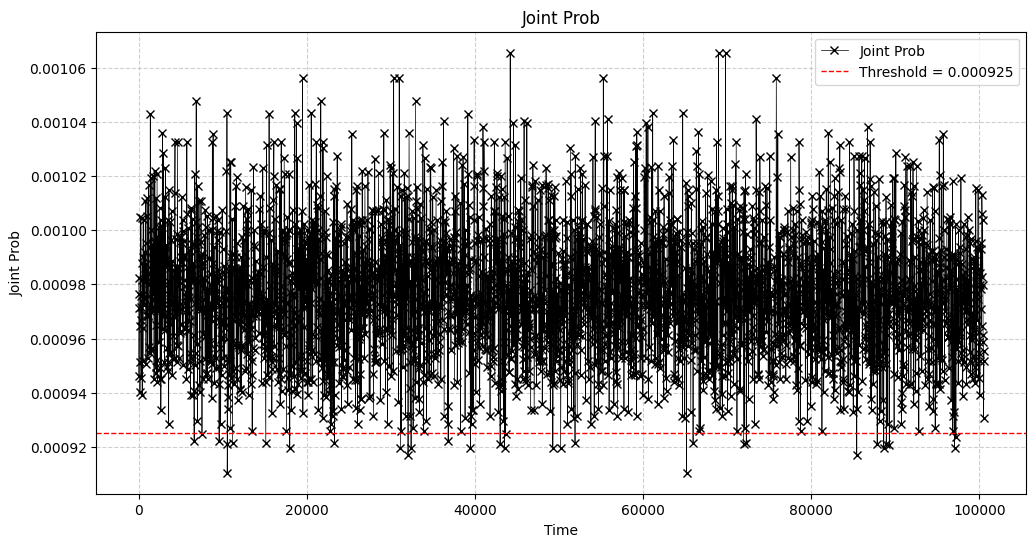

In [87]:
time = np.arange(len(joint_probabilities))

threshold = 0.000925
n = 30

plt.figure(figsize=(12, 6))

# **Plot RMSE**
plt.plot(time[::n], joint_probabilities[::n], color='black', linewidth=0.5,
         label="Joint Prob", marker='x')
plt.axhline(y=threshold, color='red', linestyle='--', linewidth=1, label=f"Threshold = {threshold}")
plt.xlabel("Time")
plt.ylabel("Joint Prob")
plt.title("Joint Prob")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

plt.show()

In [88]:
joint_probabilities = np.array(joint_probabilities)
anomaly_indices = np.where(joint_probabilities < threshold)[0]

In [94]:
len(anomaly_indices)

1072

In [89]:
anomaly_indices

array([   152,    517,    518, ..., 100376, 100425, 100507])

In [90]:
anomaly_times = time[anomaly_indices]

In [91]:
anomaly_times

array([   152,    517,    518, ..., 100376, 100425, 100507])

In [92]:
time

array([     0,      1,      2, ..., 100577, 100578, 100579])

In [99]:
df['final_label'].value_counts()

,count
final_label,
0.0,136821
1.0,5910
0.5,963


In [101]:
X_test

array([[[-0.89490717]],

       [[ 0.25985999]],

       [[-1.11142601]],

       ...,

       [[ 0.54855178]],

       [[-0.38969653]],

       [[-0.75056127]]])

In [104]:
Y_test.shape

(100586,)

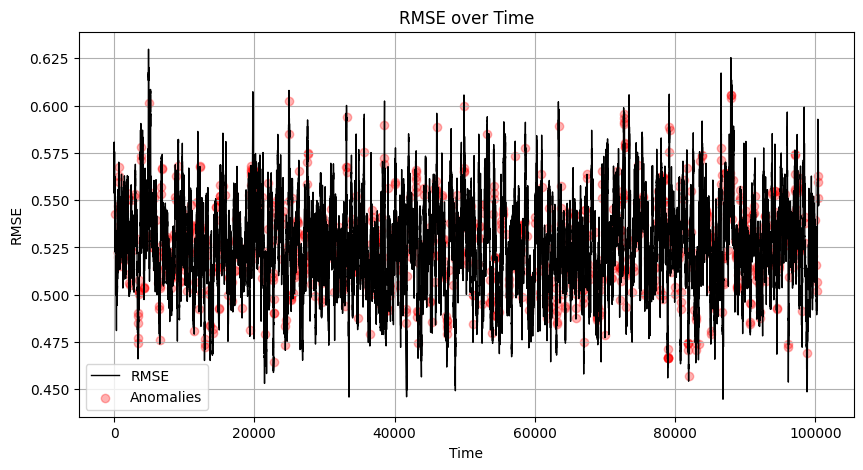

In [116]:
valid_anomaly_indices = anomaly_indices[anomaly_indices < len(rmse_smooth)]
valid_anomaly_times = time[valid_anomaly_indices]

plt.figure(figsize=(10, 5))

# Plot RMSE curve
plt.plot(time[:len(rmse_smooth)], rmse_smooth, linestyle='-', linewidth=1, color='black', label="RMSE")

# Mark anomalies with red dots
plt.scatter(valid_anomaly_times, rmse_smooth[valid_anomaly_indices], color='red', label="Anomalies", alpha=0.3)

# Labels & Title
plt.xlabel('Time')
plt.ylabel('RMSE')
plt.title('RMSE over Time')
plt.grid(True)
plt.legend()

plt.show()

In [106]:
y_pred = [1 if x in anomaly_indices else 0 for x in range(len(Y_test))]
(y_pred == Y_test).mean()

np.float64(0.9419402302507307)

In [117]:
from sklearn.decomposition import PCA
pca_X = df[['ABPd', 'ABPm', 'ABPs', 'HR', 'RR', 'SpO2', 'Temperature C']]

scaler = StandardScaler()
pca_X_scaled = scaler.fit_transform(pca_X)

pca = PCA()
pca.fit(pca_X_scaled)

PCA()

In [118]:
df.isnull().sum()

,0
ABPd,0
ABPm,0
ABPs,0
HR,0
RR,0
SpO2,0
Temperature C,0
point_anomaly,0
contextual_anomaly,0
final_label,0


In [119]:
df = df.dropna()

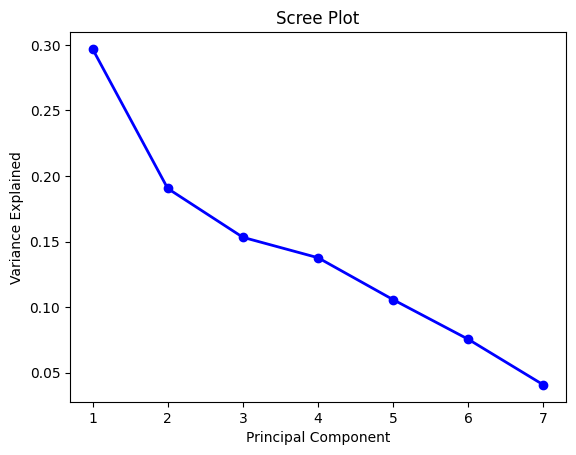

In [120]:
PC_values = np.arange(1, len(pca.explained_variance_ratio_) + 1)
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

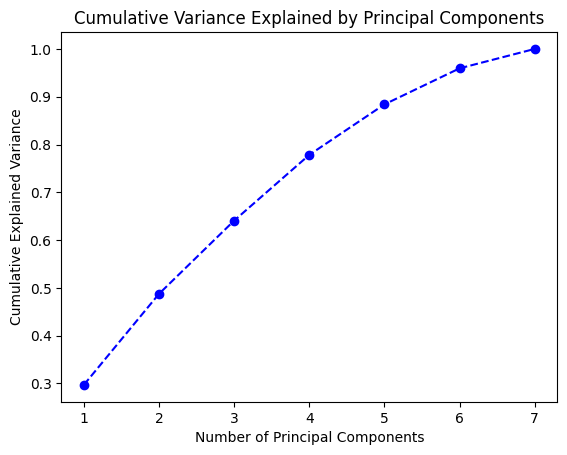

In [121]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
plt.plot(PC_values , cumulative_variance, marker='o', linestyle='--', color='b')
plt.title('Cumulative Variance Explained by Principal Components')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

In [122]:
loadings = pca.components_

loading_df = pd.DataFrame(loadings.T, index=pca_X.columns, columns=[f'PC{i+1}' for i in range(pca.n_components_)])

print("Feature Contributions to Principal Components:")
print(loading_df.abs().sort_values(by='PC1', ascending=False))

Feature Contributions to Principal Components:
                    PC1       PC2       PC3       PC4       PC5       PC6  \
ABPm           0.628079  0.017601  0.084962  0.023738  0.015963  0.073395   
ABPd           0.558869  0.032038  0.091776  0.112612  0.407132  0.510406   
ABPs           0.518514  0.263284  0.103324  0.071116  0.331164  0.636761   
SpO2           0.116313  0.318201  0.761959  0.242858  0.415329  0.191302   
HR             0.076394  0.714023  0.084372  0.026718  0.477310  0.498675   
RR             0.052082  0.507641  0.418559  0.475812  0.560241  0.153212   
Temperature C  0.047415  0.246100  0.459119  0.834030  0.100633  0.141027   

                    PC7  
ABPm           0.769274  
ABPd           0.489147  
ABPs           0.361882  
SpO2           0.191214  
HR             0.001304  
RR             0.025606  
Temperature C  0.027819  


In [ ]:
# from sklearn.metrics import mean_squared_error, r2_score

# for col in columns:
#     df_selected = df[[col, 'point_anomaly', 'contextual_anomaly', 'final_label']]
#     look_back = 5
#     X, y = create_dataset(df_selected, look_back)
#     X_train, X_test = X[:train_size], X[train_size:]
#     y_train, y_test = y[:train_size], y[train_size:]
#     model = Sequential()
#     model.add(LSTM(20, input_shape=(look_back, 4)))
#     model.add(Dense(1))
#     model.compile(loss='mean_squared_error', optimizer='adam')
#     model.fit(X_train, y_train, epochs=20, batch_size=128, verbose=1)

#     # Predict on the test set
#     y_pred = model.predict(X_test)

#     # Define a tolerance level for correct predictions (e.g., 5% of the actual value)
#     tolerance = 0.05

#     # Calculate accuracy based on the tolerance
#     correct_predictions = np.sum(np.abs(y_test - y_pred.flatten()) <= tolerance * y_test) # flattening the y_pred to ensure compatibility for vector-wise comparison
#     accuracy = correct_predictions / len(y_test)

#     print(f"Test Accuracy (Tolerance {tolerance*100:.0f}%): {accuracy:.4f}")
